In [1]:
%config InlineBackend.rc = {"figure.dpi": 72, "figure.figsize": (6.0, 4.0)}
%matplotlib inline
import ase
import matplotlib.pyplot as plt
import numpy as np

import abtem
from abtem import (
    CrystalPotential,
    FrozenPhonons,
    PhaseScramblePlasmons,
    PixelatedDetector,
    Potential,
    Probe,
)

abtem.config.set({"device": "cpu"})
abtem.config.set({"diagnostics.progress_bar": False});

(tutorials:advanced_inelastic_scattering)=
# Advanced inelastic scattering: fast plasmons and Bloch waves

This tutorial covers two faster, complementary approaches to inelastic (plasmon and phonon) scattering, both building on the Monte Carlo plasmon-scattering method of {cite}`mendis_plasmons` (2019), which draws many independent scattering events and runs a full separate multislice pass for each.

{cite}`mendis_phase_scramble` (2023) speeds this up substantially by applying the plasmon-scattering operator *inline*, at the bottom of every slice within a single multislice pass, relying on ensemble averaging (over frozen-phonon configurations, or explicit repetitions on a static structure) for statistical convergence instead of one pass per event. The same paper separately introduces a phase-scrambling scheme for combining a small, reused pool of frozen-phonon configurations in `CrystalPotential` — unrelated to plasmons, but sharing the same underlying trick of averaging over independent random phases.

{cite}`mendis_bloch_inelastic` (2024) takes a different route again: Bloch waves solve the dynamical diffraction problem by diagonalizing a structure matrix for the whole crystal rather than propagating slice by slice, so the inline phase-scramble trick has no natural hook. Instead, the same per-event Monte Carlo scattering used by the original 2019 method is interleaved directly into the Bloch-wave structure-matrix propagation.

Below we demonstrate `PhaseScramblePlasmons` (inline multislice plasmons), `CrystalPotential(mixing="phase_scramble")` (inline phonon averaging), and inelastic Bloch-wave diffraction via `BlochWaves` with `MonteCarloPlasmons`, closing with a summary of which tool suits which situation.

## Fast inline plasmon scattering with `PhaseScramblePlasmons`

`PhaseScramblePlasmons` reproduces the plasmon-scattering model of {cite}`mendis_plasmons` without the cost of a separate multislice pass per sampled scattering event: the phase-scrambling operator is applied directly after every slice within a single multislice pass, and convergence is obtained by ensemble-averaging over many independent passes — reusing a potential's frozen-phonon configuration axis (as below), or via `num_repetitions` on a static structure with no frozen phonons. It works with both `FourierMultislice` and `RealSpaceMultislice` (including real-space backscattering), and with PRISM (`SMatrix(..., plasmons=...)`).

We build a thin silicon sample and set up a small ensemble of frozen-phonon configurations, which will double as the statistical ensemble the plasmon scattering averages over.

In [2]:
atoms = ase.build.bulk("Si", cubic=True)
atoms = ase.build.surface(atoms, indices=(0, 1, 1), layers=3, periodic=True)
atoms = abtem.orthogonalize_cell(atoms)
atoms *= (2, 2, 25)
atoms.center()

frozen_phonons = FrozenPhonons(atoms, num_configs=8, sigmas=0.078, ensemble_mean=True)

potential = Potential(frozen_phonons, gpts=256, slice_thickness=1.92)

print(f"thickness = {potential.thickness:.1f} Å, gpts = {potential.gpts}")

thickness = 288.0 Å, gpts = (256, 256)


We set up a `PhaseScramblePlasmons` object with the same plasmon parameters used for silicon in the Bloch-wave section below and in {cite}`mendis_bloch_inelastic`: a mean free path of $1050 \ \mathrm{Å}$, an excitation energy of $16.7 \ \mathrm{eV}$ and a critical angle of $19.1 \ \mathrm{mrad}$. Setting `max_loss_order=2` tells the multislice loop to keep separate, simultaneously-propagated wave functions for the zero-loss, single- and double-plasmon channels, each weighted by its Poisson probability at the local depth.

In [3]:
plasmons = PhaseScramblePlasmons(
    mean_free_path=1050.0,
    excitation_energy=16.7,
    critical_angle=19.1,
    max_loss_order=2,
    seed=0,
)

probe = Probe(energy=200e3, semiangle_cutoff=3.9, Cs=1e7, defocus=-600)
probe.grid.match(potential)

detector = PixelatedDetector(max_angle="valid")

orders = probe.build().multislice(potential, detector, plasmons=plasmons).compute()

orders.axes_metadata

type                 label          coordinates
-------------------  -------------  --------------------
OrdinalAxis          Plasmon order  -
ReciprocalSpaceAxis  kx [1/Å]       -3.87 -3.78 ... 3.78
ReciprocalSpaceAxis  ky [1/Å]       -3.91 -3.84 ... 3.84

A single multislice pass now returns one diffraction pattern per loss order, labelled "Zero loss", "1-plasmon" and "2-plasmon" — no separate multislice run was needed per excitation, unlike the per-event Monte Carlo approach. We show the three channels side by side; the pattern broadens and the central disk loses intensity as the loss order increases, exactly as in the Monte Carlo plasmon result, but obtained roughly two orders of magnitude faster since only one multislice pass over the ensemble of frozen-phonon configurations was required.

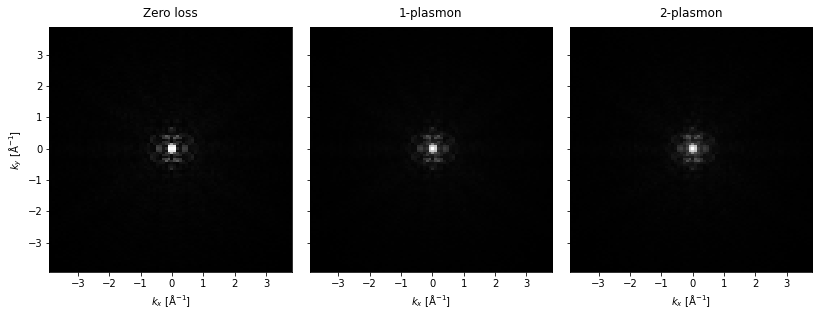

In [4]:
orders.show(explode=True, figsize=(12, 4), cmap="gray", power=0.5);

### Estimating parameters from the structure

Calibrated plasmon parameters (as above) are best obtained from experiment, but `PhaseScramblePlasmons.from_atoms` gives a quick free-electron (jellium) estimate to get started. Passing the number of valence electrons explicitly avoids an optional dependency on the `mendeleev` package. Only the excitation energy estimate is reliable (within a few percent of the literature value for materials like Si and GaAs); the critical angle and mean free path are order-of-magnitude free-electron estimates only, and should be replaced with calibrated (e.g. EELS-measured) values for quantitative work, as we did above.

In [5]:
est_energy, est_angle, est_mfp = abtem.inelastic.plasmons.estimate_plasmon_parameters(
    atoms, energy=200e3, valence_electrons=4
)

print(f"estimated excitation energy: {est_energy:.1f} eV   (literature: 16.7 eV)")
print(f"estimated critical angle:    {est_angle:.2f} mrad  (literature: 19.1 mrad)")
print(f"estimated mean free path:    {est_mfp:.0f} Å        (literature: 1050 Å)")

estimated excitation energy: 16.6 eV   (literature: 16.7 eV)
estimated critical angle:    4.81 mrad  (literature: 19.1 mrad)
estimated mean free path:    1712 Å        (literature: 1050 Å)


As advertised, the excitation-energy estimate is close to the literature value, while the critical angle and mean free path estimates are only order-of-magnitude — here the critical-angle estimate is about 4$\times$ smaller than the calibrated literature value, and the mean-free-path estimate is about 1.6$\times$ larger — underlining that those two parameters should be calibrated against experiment (or taken from the literature, as with the $19.1\ \mathrm{mrad}$ and $1050\ \mathrm{Å}$ values used above) rather than relied on as free-electron estimates.

## Phase-scrambled thermal diffuse scattering with `CrystalPotential`

The same 2023 paper also introduces an unrelated-to-plasmons but same-name-sharing contribution: a new way of combining frozen-phonon configurations across the lateral tiles of a `CrystalPotential`.

The existing default, `mixing="random"`, draws one frozen-phonon configuration per lateral tile from the pool, which requires a large pool (at least `repetitions[0] * repetitions[1] * repetitions[2]` configurations) to avoid spurious coherent artifacts — visible as unphysical extra intensity near HOLZ rings — when a small pool is reused across many tiles.

`mixing="phase_scramble"` instead coherently combines *every* pool configuration's transmission function at each sub-slice, with an independent random phase per configuration. This is the correct way to approximate thermal diffuse scattering from a deliberately small, reused pool (the "MSP"/phase-scrambling scenario described by {cite}`mendis_phase_scramble`), rather than an approximation error to be worked around with a bigger pool.

```{warning}
The frozen phonons used with `mixing="phase_scramble"` should be generated with `directions="xy"`. Since the combination mixes configurations *within* every slice, a $z$-displacement that moves an atom across a slice boundary in some configurations but not others contaminates the coherent sum with atom-count-violating pathways — even though a $z$-displacement does not by itself change a slice's projected potential. `mixing="phase_scramble"` warns at runtime if `z`-displacements are present in the pool.
```

In [6]:
unit_cell = ase.build.bulk("Si", cubic=True)

unit_frozen_phonons = FrozenPhonons(
    unit_cell, num_configs=10, sigmas=0.078, directions="xy", seed=1
)

unit_potential = Potential(
    unit_frozen_phonons, gpts=128, slice_thickness=1.36
).build(lazy=False)

crystal_random = CrystalPotential(unit_potential, repetitions=(6, 6, 20), mixing="random")
crystal_scramble = CrystalPotential(
    unit_potential, repetitions=(6, 6, 20), mixing="phase_scramble"
)

print(f"pool size: {unit_potential.num_configurations}, lateral tiles: {6 * 6}")

pool size: 10, lateral tiles: 36


Here the pool of 10 configurations is much smaller than the $6\times6=36$ lateral tiles, exactly the "small, reused pool" scenario the phase-scrambling algorithm addresses. We run both mixing modes with an aberration-free probe and compare the resulting diffraction patterns.

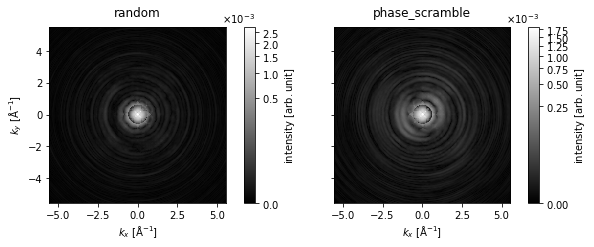

In [7]:
probe_crystal = Probe(energy=200e3, semiangle_cutoff=15)
probe_crystal.grid.match(crystal_random)

detector_crystal = PixelatedDetector(max_angle="valid")

dp_random = probe_crystal.build().multislice(crystal_random, detector_crystal).compute()
dp_scramble = (
    probe_crystal.build().multislice(crystal_scramble, detector_crystal).compute()
)

comparison = abtem.stack(
    [dp_random, dp_scramble], axis_metadata={"label": "mixing", "values": ["random", "phase_scramble"]}
)

comparison.show(explode=True, figsize=(9, 4), cmap="gray", power=0.3, cbar=True);

Both patterns show the same Bragg disks and overall diffuse background; with only 10 pool configurations reused across 36 tiles, `mixing="random"` is prone to weak, spurious coherent features that would keep sharpening with more repeated tiling, whereas `mixing="phase_scramble"` remains a well-behaved incoherent-looking diffuse background at this pool size, as it samples every pool member's contribution simultaneously rather than forcing a single (repeated) draw per tile.

In [8]:
%config InlineBackend.rc = {"figure.dpi": 72, "figure.figsize": (6.0, 4.0)}
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk

import abtem
from abtem import BlochWaves
from abtem.inelastic.plasmons import MonteCarloPlasmons

abtem.config.set({"device": "cpu"})
abtem.config.set({"diagnostics.progress_bar": False});

## Bloch-wave inelastic scattering

Bloch waves solve the dynamical diffraction problem by diagonalizing a structure matrix built from the whole 3D crystal, rather than propagating an exit wave slice by slice as multislice does — so there is no per-slice hook for the inline phase-scramble trick used above. {cite}`mendis_bloch_inelastic` instead interleaves the existing per-event `MonteCarloPlasmons` (and an analogous `MonteCarloPhonons`) Monte Carlo scattering directly into the Bloch-wave structure-matrix propagation, re-diagonalizing after every sampled scattering event, and adds a deterministic depth-slice alternative for a smooth diffuse background without Monte Carlo noise. This is integrated into *ab*TEM's existing `BlochWaves` dynamical-diffraction API — the same engine used for CBED and other dynamical-diffraction simulations.

We set up a small silicon Bloch-wave calculation with a coarse `g_max` (few enough beams to run quickly on a CPU) and reuse the plasmon parameters from the multislice example above.

In [9]:
si = bulk("Si", cubic=True)

bw = BlochWaves(structure_factor=si, energy=200e3, sg_max=0.05, g_max=3.0, centering="F")

print(f"number of beams included: {len(bw)}")

number of beams included: 97


We reuse the same plasmon parameters as in the fast multislice example above ($\lambda_p = 1050 \ \mathrm{Å}$, $E_p = 16.7 \ \mathrm{eV}$, $\theta_c = 19.1 \ \mathrm{mrad}$), but this time via `MonteCarloPlasmons` — the same per-event Monte Carlo class used by the original {cite}`mendis_plasmons` multislice method. Bloch waves propagate the whole crystal in one eigendecomposition rather than slice by slice, so the inline phase-scramble trick from the previous sections does not apply here; instead {cite}`mendis_bloch_inelastic` couples the Bloch-wave structure-matrix propagation to the same per-event Monte-Carlo scattering-angle sampling, re-diagonalizing the structure matrix after every sampled event.

`calculate_diffraction_patterns` accepts this `plasmons` object directly and returns an energy-filtered, excitation-order-resolved set of diffraction patterns: one pattern per number of plasmon excitations, incoherently averaged over the Monte Carlo samples of that order and weighted by the Poisson probabilities stored in the result's metadata.

In [10]:
plasmons = MonteCarloPlasmons(
    mean_free_path=1050.0,
    excitation_energy=16.7,
    critical_angle=19.1,
    num_excitations=2,
    num_samples=30,
    seed=42,
)

dp = bw.calculate_diffraction_patterns(300.0, plasmons=plasmons, lazy=False)

print("plasmon orders:", dp.metadata["plasmon_orders"])
print("Poisson weights:", [f"{w:.3f}" for w in dp.metadata["plasmon_weights"]])

plasmon orders: (0, 1, 2)
Poisson weights: ['0.751', '0.215', '0.031']


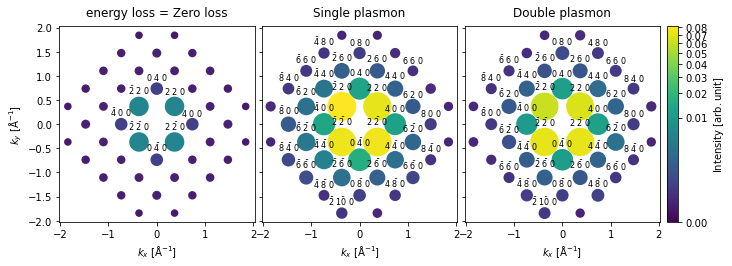

In [11]:
dp.block_direct().show(
    explode=True, figsize=(11, 4), scale=0.3, power=0.3, cbar=True, common_color_scale=True
);

As with the multislice `PhaseScramblePlasmons` result, the zero-loss pattern is the sharpest, and the diffuse background around each Bragg disk grows with excitation order, here obtained entirely within the Bloch-wave dynamical-diffraction framework rather than multislice.

### Deterministic diffuse-scattering patterns

Sampling scattering events with Monte Carlo, as above, leaves shot noise in the diffuse background. {cite}`mendis_bloch_inelastic` also gives a deterministic alternative: `calculate_diffuse_dp_deterministic` divides the specimen into depth slices and, for every scattering-angle pixel of the output grid, deflects the beam by that angle, re-diagonalizes the structure matrix, and propagates to the exit surface — trading Monte Carlo noise for a systematic (but smooth) rigid-shift approximation, evaluated at a finite number of depth slices.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


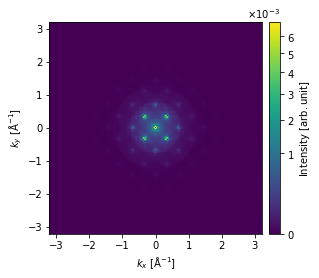

In [12]:
dp_diffuse = bw.calculate_diffuse_dp_deterministic(
    thickness=500.0,
    plasmons=plasmons,
    num_slices=6,
    dp_full=80.0,
    dp_step=1.0,
)

dp_diffuse.show(power=0.5, cbar=True, figsize=(5, 4));

The result is a smooth, noise-free diffuse halo around the transmitted beam, without any Monte Carlo sampling — useful when a clean diffuse background is wanted without averaging over many random configurations. `MonteCarloPhonons` (same module) offers an analogous, thermal-diffuse-scattering counterpart to `MonteCarloPlasmons`, using a `thermal_sigma` in place of the plasmon parameters, and can be interleaved with plasmon scattering in the same simulation.

## Which tool for which job

* **`MonteCarloPlasmons` in ordinary multislice** (the per-event Monte Carlo method of {cite}`mendis_plasmons`) — one full multislice pass per sampled scattering event. The most direct and simplest implementation of the method, and a good starting point, but its cost scales with the number of Monte Carlo samples needed for convergence.
* **`PhaseScramblePlasmons`** — inline, single-pass plasmon scattering for ordinary multislice and PRISM ({cite}`mendis_phase_scramble`). Much faster than the per-event approach above, trading exact per-event sampling for statistical (ensemble) convergence.
* **`CrystalPotential(mixing="phase_scramble")`** — a related but independent thermal-diffuse-scattering mode for a small, reused frozen-phonon pool tiled over a large crystal, avoiding the spurious coherent artifacts that the default `mixing="random"` can produce at small pool sizes ({cite}`mendis_phase_scramble`).
* **Bloch-wave inelastic scattering** (`BlochWaves` with `MonteCarloPlasmons`/`MonteCarloPhonons`) — for dynamical diffraction and CBED-style simulations where Bloch waves, rather than multislice, are the natural framework; gives energy-filtered, excitation-order-resolved patterns, plus a deterministic depth-slice alternative for a noise-free diffuse background ({cite}`mendis_bloch_inelastic`).
